In [4]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp

# Make project root importable when running from Modeling/tasks/Basic_FE_sweeps
project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

from Modeling.models.FE3 import PiezoBeamFE
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models import FE_helpers

# 1) FE model
params = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3)
fe = PiezoBeamFE(params)

# 2) Chirp first, then hold the last frequency as a harmonic excitation
amp = 50
f0 = 500
f = 5000
t1 = 20
t_end = t1
dt = 1 / f/ 50
# Start from 0 Hz and sweep up to f over [0, t1], then continue at f
def v_exc(t):
    if t < t1:
        return amp * chirp(t, f0=0, f1=f, t1=t1, method="linear")
    return amp * np.cos(2 * np.pi * f * t)

def v_exc(t):
    return amp * chirp(t, f0=0, f1=f, t1=t1, method="linear")
# plt.figure(figsize=(8, 3))
# t_plot = np.arange(0, t_end, dt)
# plt.plot(t_plot, [v_exc(t) for t in t_plot])
# plt.xlabel('time [s]')
# plt.xlim(0.495, 0.505)
# plt.show()


In [ ]:

ode = fe.build_ode_system(
    j_exc=30,
    K_p=0.015,
    K_i=1820,
    K_c=3e10,
    R_c=1e3,
    v_exc=v_exc,
)

# 3) Time-domain solve (kept intentionally short for a quick baseline run)
out = FE_helpers.solve_newmark(
    ode=ode,
    dt=dt,  # 80 points per cycle
    t_end=t_end,
    beta=0.25,
    gamma=0.5,
    do_spectral=False,
)


Newmark Integration:   0%|          | 0/5000000 [00:00<?, ?step/s]

Newmark Integration:   0%|          | 15119/5000000 [00:40<3:40:49, 376.23step/s]

In [ ]:
out['u_ddot'].shape 

(200000, 157)

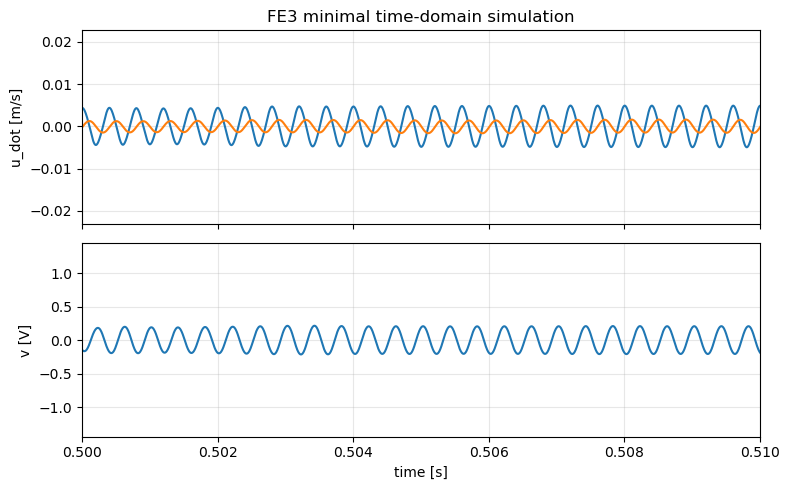

u_dot shape: (200000, 157)
v shape: (200000, 30)


In [ ]:
# 4) Plot one mechanical and one electrical response channel
t = out['t']
mech_idx = 75
elec_idx = 10
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(t, out['u_dot'][:, mech_idx], label= 'u_dot')
ax[0].plot(t, out['u'][:, mech_idx]*5000, label= 'u')
ax[0].set_ylabel('u_dot [m/s]')
ax[0].set_title('FE3 minimal time-domain simulation')
ax[0].grid(True, alpha=0.3)

ax[1].plot(t, out['v'][:, elec_idx])
ax[1].set_ylabel('v [V]')
ax[1].set_xlabel('time [s]')
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(0.5, 0.51)
plt.tight_layout()
plt.show()

print('u_dot shape:', out['u_dot'].shape)
print('v shape:', out['v'].shape)